In [93]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

from optical.surface import WaterSruface
from optical.quartic_solver.feralli import solve_quartic_ferrari
from optical.quartic_solver.newton_method import solve_quartic_newton

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
# Choose dataset by flag or name
dataset_flag = "river2"  # Change this flag to "river1" or "river2" as needed
home_dir = os.path.expanduser("~")

if dataset_flag == "river1":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_with-refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river_wo-refraction"))
    non_refraction_model_path = os.path.abspath("../../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply")
elif dataset_flag == "river2":
    wo_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction"))
    with_refraction_dataset_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/refraction"))
    non_refraction_model_path = os.path.abspath(os.path.join(home_dir, "dataset/river2/wo_refraction_wo_plane/cut_sphere.ply"))
else:
    raise ValueError(f"Unknown dataset flag: {dataset_flag}")

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.


In [95]:
data = dataloader_ref.dataset[80]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 

# camtoworlds = torch.Tensor(
#     [[
#         [1, 0, 0, 0],
#         [0, 1, 0, 0],
#         [0, 0, 1, 100],
#         [0, 0, 0, 1]
#     ]]
# ).to(device)  
print(camtoworlds)

worldtocam = camtoworlds.inverse()
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)

tensor([[[ 0.3420,  0.7198, -0.6040, 12.0805],
         [ 0.9397, -0.2620,  0.2198, -4.3969],
         [ 0.0000, -0.6428, -0.7660,  5.3209],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='cuda:0')
('train', '0080.png')


In [190]:
scale_abs = torch.tensor(5).to(device)  
opacity_abs = torch.tensor(0.99).to(device)  

scale_param = torch.log(scale_abs)
opacity_param = torch.logit(opacity_abs)  
print(scale_param, opacity_param)

# create one simple gaussian model
means  = torch.tensor([[0.0, 0.0, -10.0],
                       [0.0, 5.0, -10.0],
                       [5.0, 5.0, -10.0],]).to(device) # shape: [1, 3]
scales  = torch.tensor([[scale_param, scale_param, 0.0],
                        [scale_param, scale_param, 0.0],
                        [scale_param, scale_param, 0.0]]).to(device)  # shape: [1, 3]
quats  = torch.tensor([[1.0, 0.0, 0.0, 0.0],
                       [1.0, 0.0, 0.0, 0.0],
                       [1.0, 0.0, 0.0, 0.0]]).to(device)  # shape: [1, 4]
opacities  = torch.tensor([opacity_abs,
                           opacity_abs,
                           opacity_abs]).to(device)  # shape: [1,]
colors  = torch.tensor([[[1.0, 0.0, 0.0]],
                        [[0.0, 1.0, 0.0]],
                        [[0.0, 0.0, 1.0]]]).to(device)  # shape: [1, 1, 3]

tensor(1.6094, device='cuda:0') tensor(4.5951, device='cuda:0')


In [191]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSruface(
    means=means,
    quats=quats,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=False,
)

trandformed_means, trandformed_quats = WS.transform_to_appearance()


In [192]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [193]:
# 補正後の Gaussian を用いてレンダリング (回転なし)
rgb_refraction_wo_quats, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_wo_quats = rgb_refraction_wo_quats.squeeze().cpu().detach().numpy()

In [194]:
# 補正後の Gaussian を用いてレンダリング (回転補正)
rgb_refraction_with_quats, _, _ = rasterization(
    trandformed_means,
    trandformed_quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction_with_quats = rgb_refraction_with_quats.squeeze().cpu().detach().numpy()

GT image without refraction: /home/taiki/dataset/river2/wo_refraction/train/0080.png
GT image with refraction: /home/taiki/dataset/river2/refraction/train/0080.png


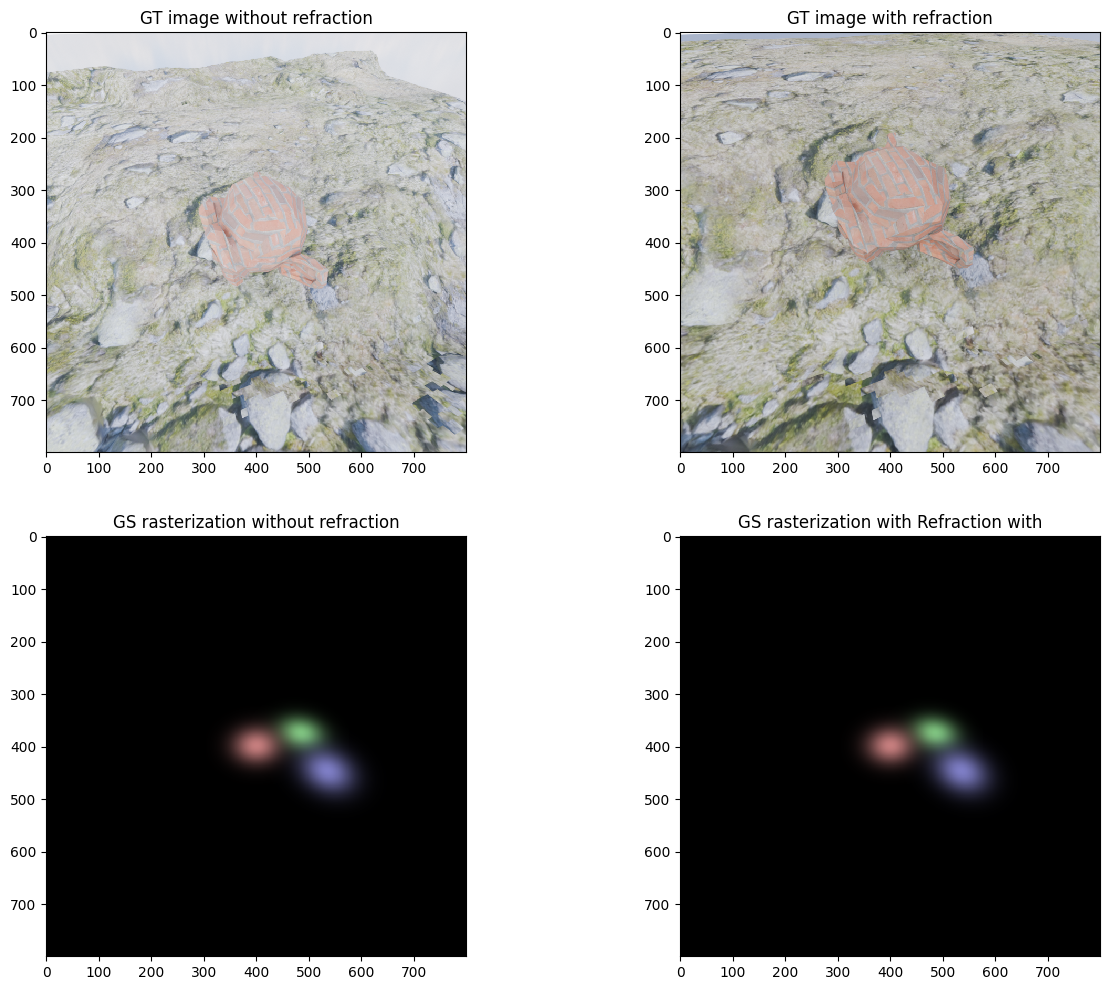

In [195]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction_wo_quats)
ax[1, 1].set_title("GS rasterization with Refraction with")
plt.show()

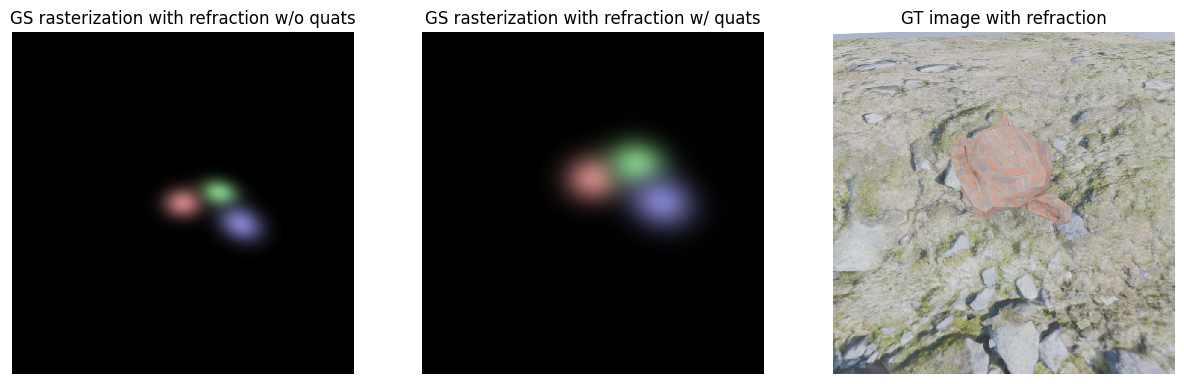

In [196]:
fig, axes = plt.subplots(1, 3)
images = [
    (rgb_refraction_wo_quats, "GS rasterization with refraction w/o quats"),
    (rgb_refraction_with_quats, "GS rasterization with refraction w/ quats"),
    (gt_image_with_ref, "GT image with refraction"),
]
for ax, (img, title) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.show()


In [197]:
from internal.utils.gaussian_utils import GaussianTransformUtils
from optical.utils.rotation_utils import quat_from_2dirs, quat_to_rotmat


ray_intersec2gaussian = WS.ray_intersec2gaussian
ray_to_apparent = WS.ray_to_apparent

d_q = quat_from_2dirs(ray_intersec2gaussian, ray_to_apparent)
print("d_q \n", d_q)

rotmat = quat_to_rotmat(d_q)
print("rotmat \n", rotmat)


d_q 
 tensor([[ 9.9227e-01,  4.2444e-02,  1.1661e-01, -4.0083e-09],
        [ 9.8919e-01,  9.0043e-02,  1.1576e-01,  4.9277e-08],
        [ 9.9350e-01,  9.0881e-02,  6.8478e-02,  8.2531e-08]], device='cuda:0')
rotmat 
 tensor([[[ 0.9728,  0.0099,  0.2314],
         [ 0.0099,  0.9964, -0.0842],
         [-0.2314,  0.0842,  0.9692]],

        [[ 0.9732,  0.0208,  0.2290],
         [ 0.0208,  0.9838, -0.1781],
         [-0.2290,  0.1781,  0.9570]],

        [[ 0.9906,  0.0124,  0.1361],
         [ 0.0124,  0.9835, -0.1806],
         [-0.1361,  0.1806,  0.9741]]], device='cuda:0')


In [198]:
new_quats = GaussianTransformUtils.quat_multiply(quats, d_q)
print("new_quats \n", new_quats)

diff_dir = ray_intersec2gaussian - ray_to_apparent
print("diff_dir \n", diff_dir)

new_quats 
 tensor([[ 9.9227e-01,  4.2444e-02,  1.1661e-01, -4.0083e-09],
        [ 9.8919e-01,  9.0043e-02,  1.1576e-01,  4.9277e-08],
        [ 9.9350e-01,  9.0881e-02,  6.8478e-02,  8.2531e-08]], device='cuda:0')
diff_dir 
 tensor([[ 0.1748, -0.0636, -0.1643],
        [ 0.1599, -0.1244, -0.2121],
        [ 0.1065, -0.1413, -0.1431]], device='cuda:0')


In [199]:
print("ray_intersec2gaussian \n", ray_intersec2gaussian)
print("ray_to_apparent \n", ray_to_apparent)

ray_intersec2gaussian 
 tensor([[-0.5298,  0.1928, -0.8259],
        [-0.4846,  0.3770, -0.7893],
        [-0.3227,  0.4282, -0.8441]], device='cuda:0')
ray_to_apparent 
 tensor([[-0.7046,  0.2565, -0.6617],
        [-0.6445,  0.5014, -0.5773],
        [-0.4292,  0.5696, -0.7010]], device='cuda:0')
